[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TarannumAhmedNowshin/Automated-Essay-Scoring/blob/main/transformermodels/muril-small.ipynb)


# MuRIL — Automated Essay Scoring (small dataset)

Fine-tunes Google's [MuRIL](https://huggingface.co/google/muril-base-cased)
(Multilingual Representations for Indian Languages) as a **regression** model that
predicts an essay score (0–10) from a `Question` + `Answer` pair, on the **small**
dataset (~325 graded scripts).

This notebook contains two experiments on the same small dataset:

1. **MuRIL base** (`google/muril-base-cased`, 768-d) with a deeper regression head — first code cell.
2. **MuRIL large** (`google/muril-large-cased`, 1024-d) — later code cell, with loss curves and error plots.

Each model mean-pools the last hidden state, adds a regression head, and reports
**RMSE**, **MAE**, and **R²** on the train / validation / test splits.

> Place the dataset in a local `data/` folder first — see the repo's
> [data/README.md](../data/README.md) for the expected columns.


In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import torch.nn as nn
from transformers import AdamW, get_linear_schedule_with_warmup
from torch.amp import GradScaler, autocast

# Load the data (place the CSV in a local `data/` folder next to this notebook)
path = os.path.join("data", "essays_small.csv")
data = pd.read_csv(path)

# Debug: Print the first few rows and check the columns
print(data.head())
print(data.columns)

# Preprocess dataset
data['Marks'] = pd.to_numeric(data['Marks'], errors='coerce')
data = data.dropna(subset=['Marks'])
data['Marks'] = data['Marks'].astype(float)

# Split dataset
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Define Dataset class
class BanglaEssayDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        question = str(self.data.iloc[idx]['Question'])
        answer = str(self.data.iloc[idx]['Answer'])
        marks = float(self.data.iloc[idx]['Marks'])

        text = question + " " + answer

        inputs = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )

        return {
            'input_ids': inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze(),
            'labels': torch.tensor(marks, dtype=torch.float)
        }

# Initialize tokenizer and model
# Use MURIL Base for faster computation
tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")
model = AutoModel.from_pretrained("google/muril-base-cased")

# Initialize datasets with reduced max_len
train_dataset = BanglaEssayDataset(train_data, tokenizer, max_len=128)
val_dataset = BanglaEssayDataset(val_data, tokenizer, max_len=128)
test_dataset = BanglaEssayDataset(test_data, tokenizer, max_len=128)

# Create DataLoaders with reduced batch size
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=4, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=4, num_workers=4)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
num_epochs = 25
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps)

# Define enhanced regression head
regression_head = nn.Sequential(
    nn.Linear(768, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
).to(device)

# Define loss function
loss_fn = nn.MSELoss()

# Mixed precision setup
scaler = GradScaler()

# Training loop with gradient accumulation
accumulation_steps = 4
best_val_r2 = float('-inf')
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    optimizer.zero_grad()

    for i, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).float()

        with autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state
            pooled_output = last_hidden_state.mean(dim=1)

            preds = regression_head(pooled_output).squeeze(-1)
            loss = loss_fn(preds, labels) / accumulation_steps

        scaler.scale(loss).backward()
        if (i + 1) % accumulation_steps == 0 or i == len(train_loader) - 1:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_train_loss += loss.item() * accumulation_steps

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation loop
    model.eval()
    total_val_loss = 0
    val_predictions, val_actuals = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state
            pooled_output = last_hidden_state.mean(dim=1)

            preds = regression_head(pooled_output).squeeze(-1)
            loss = loss_fn(preds, labels)
            total_val_loss += loss.item()

            val_predictions.extend(preds.cpu().numpy())
            val_actuals.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_r2 = r2_score(val_actuals, val_predictions)

    print(f"Epoch {epoch + 1}, Training Loss: {avg_train_loss}, Validation Loss: {avg_val_loss}, Validation R^2: {val_r2}")

    # Save the best model based on validation R^2
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_model_state = {
            'model_state': model.state_dict(),
            'regression_head_state': regression_head.state_dict(),
            'optimizer_state': optimizer.state_dict()
        }

# Load the best model state
model.load_state_dict(best_model_state['model_state'])
regression_head.load_state_dict(best_model_state['regression_head_state'])

# Evaluation metrics for test data
model.eval()
test_predictions, test_actuals = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state
        pooled_output = last_hidden_state.mean(dim=1)

        preds = regression_head(pooled_output).squeeze(-1)

        test_predictions.extend(preds.cpu().numpy())
        test_actuals.extend(labels.cpu().numpy())

# Calculate metrics for validation and test sets
metrics = {}

for name, actuals, preds in zip(['Validation', 'Test'], [val_actuals, test_predictions], [val_predictions, test_actuals]):
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)

    metrics[name] = {'RMSE': rmse, 'MAE': mae, 'R^2': r2}

# Display metrics
for name, metric in metrics.items():
    print(f"{name} Metrics: RMSE: {metric['RMSE']}, MAE: {metric['MAE']}, R^2: {metric['R^2']}")

# Show ten true vs predicted scores
print("\nTen True vs Predicted Scores:")
for true, pred in zip(test_actuals[:10], test_predictions[:10]):
    print(f"True: {true}, Predicted: {pred}")


                FileName                                             Answer  \
0             NAILA GANI  সভ্যতার শুরু থেকেই পুরুষরা প্রতিষ্ঠিত থাকলেও ন...   
1   MAISHA BINTE MONOWAR  বেগম রোকেয়া তাঁর সাহিত্যকর্মের মাঝে তুলে ধরেছে...   
2            SHOURI SAHA  ১৯৪৭ সালের ভারতবর্ষ ভাগের পর থেকে প্রায় ২৫ বছর...   
3        NOSHIN TABASSUM  সম্প্রতি পঠিত “অবরোধবাসিনী” লেখাটি বর্তমান সময...   
4  SYEDA SUMAIYA TASNEEM  যুগের পর যুগ এ উপমহাদেশের নারী সম্প্রদায় নানার...   

  Marks                                           Question  \
0     9  নারীর জীবনসংগ্রাম:  অবরোধবাসিনী থেকে মুক্তিযুদ...   
1     8  নারীর জীবনসংগ্রামঃ অবরোধবাসিনী থেকে মুক্তিযুদ্ধ\n   
2     8   বাংলাদেশের মুক্তিযুদ্ধ : তরুণ প্রজন্মের ভাবনা \n   
3     8   নারীর জীবনসংগ্রাম: অবরোধবাসিনী থেকে মুক্তিযুদ...   
4   8.5   নারীর জীবনসংগ্রাম: অবরোধবাসিনী থেকে মুক্তিযুদ...   

                                            Feedback         Folder  
0                            আরও বানান-সচেতনতা দরকার  27 COPIES - 1  
1  তুলনাটা অ

c:\Users\T2410207\Anaconda3\envs\muril\lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


## MuRIL large on the same dataset

Repeats the experiment with the larger `google/muril-large-cased` (1024-d, 24
layers) and a longer sequence length (512), tracking train/validation loss.


Some weights of the model checkpoint at google/muril-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
c:\Users\T2410207\Anaconda3\envs\muril\lib\site-packages\transformers\optimization.py:591: FutureWarning: This imple

Epoch 1, Training Loss: 12.059605457566, Validation Loss: 0.6814683452248573
Epoch 2, Training Loss: 0.87032137901494, Validation Loss: 0.6568577401340008
Epoch 3, Training Loss: 0.6927950409325686, Validation Loss: 0.3867676258087158
Epoch 4, Training Loss: 0.7170796534328749, Validation Loss: 0.394209336489439
Epoch 5, Training Loss: 0.6497257586681482, Validation Loss: 0.46019141376018524
Epoch 6, Training Loss: 0.6757927491809382, Validation Loss: 0.44025544822216034
Epoch 7, Training Loss: 0.6599404233874697, Validation Loss: 0.527154840528965
Epoch 8, Training Loss: 0.6647636540177645, Validation Loss: 0.3566295653581619
Epoch 9, Training Loss: 0.6475466318202742, Validation Loss: 0.45849714428186417
Epoch 10, Training Loss: 0.5625911558216269, Validation Loss: 0.46943241357803345
Epoch 11, Training Loss: 0.4700165038759058, Validation Loss: 0.5293944776058197
Epoch 12, Training Loss: 0.4719769319124294, Validation Loss: 0.388303279876709
Epoch 13, Training Loss: 0.39435600624843

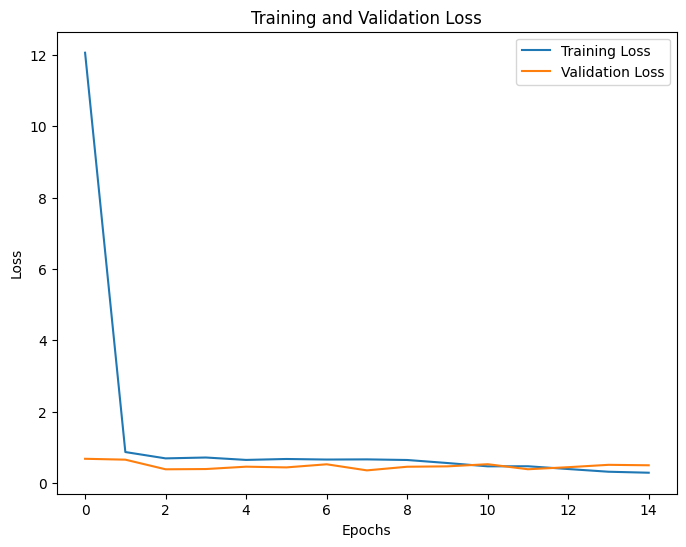


Training Set Metrics:
  RMSE: 0.7067
  MAE: 0.6220
  R-squared: -0.3787

Validation Set Metrics:
  RMSE: 0.7067
  MAE: 0.6220
  R-squared: -0.3787

Testing Set Metrics:
  RMSE: 0.7586
  MAE: 0.5787
  R-squared: 0.5650

True vs Predicted Marks (Test Set):
True Marks: 8.50, Predicted Marks: 8.56
True Marks: 7.50, Predicted Marks: 7.22
True Marks: 8.50, Predicted Marks: 7.97
True Marks: 2.00, Predicted Marks: 4.09
True Marks: 8.00, Predicted Marks: 7.69
True Marks: 7.00, Predicted Marks: 7.87
True Marks: 8.25, Predicted Marks: 8.15
True Marks: 8.00, Predicted Marks: 7.94
True Marks: 7.50, Predicted Marks: 8.12
True Marks: 6.00, Predicted Marks: 7.91


In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import torch.nn as nn
from transformers import AdamW, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt

# Load the data (place the CSV in a local `data/` folder next to this notebook)
path = os.path.join("data", "essays_small.csv")
data = pd.read_csv(path)

# Preprocess dataset
data['Marks'] = pd.to_numeric(data['Marks'], errors='coerce')
data = data.dropna(subset=['Marks'])
data['Marks'] = data['Marks'].astype(float)

# Split dataset
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Define Dataset class
class BanglaEssayDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        question = str(self.data.iloc[idx]['Question'])
        answer = str(self.data.iloc[idx]['Answer'])
        marks = float(self.data.iloc[idx]['Marks'])

        text = question + " " + answer

        inputs = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )

        return {
            'input_ids': inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze(),
            'labels': torch.tensor(marks, dtype=torch.float)
        }

# Initialize tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("google/muril-large-cased")
model = AutoModel.from_pretrained("google/muril-large-cased")

# Initialize datasets
train_dataset = BanglaEssayDataset(train_data, tokenizer, max_len=512)
val_dataset = BanglaEssayDataset(val_data, tokenizer, max_len=512)
test_dataset = BanglaEssayDataset(test_data, tokenizer, max_len=512)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
num_epochs = 15
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# Define regression head with dropout
class RegressionHead(nn.Module):
    def __init__(self, input_dim):
        super(RegressionHead, self).__init__()
        self.dropout = nn.Dropout(0.3)
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = self.dropout(x)
        return self.linear(x)

regression_head = RegressionHead(input_dim=1024).to(device)

# Define loss function
loss_fn = nn.MSELoss()

# Training loop
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).float()

        model.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        last_hidden_state = outputs.last_hidden_state
        pooled_output = last_hidden_state.mean(dim=1)

        preds = regression_head(pooled_output).squeeze(-1)
        loss = loss_fn(preds, labels)

        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation loop
    model.eval()
    total_val_loss = 0
    val_predictions, val_actuals = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state
            pooled_output = last_hidden_state.mean(dim=1)

            preds = regression_head(pooled_output).squeeze(-1)
            loss = loss_fn(preds, labels)
            total_val_loss += loss.item()

            val_predictions.extend(preds.cpu().numpy())
            val_actuals.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}, Training Loss: {avg_train_loss}, Validation Loss: {avg_val_loss}")

# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Evaluate on test set
model.eval()
test_predictions, test_actuals = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state
        pooled_output = last_hidden_state.mean(dim=1)

        preds = regression_head(pooled_output).squeeze(-1)

        test_predictions.extend(preds.cpu().numpy())
        test_actuals.extend(labels.cpu().numpy())

# Calculate metrics
def calculate_metrics(actuals, preds):
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    return rmse, mae, r2

train_rmse, train_mae, train_r2 = calculate_metrics(val_actuals, val_predictions)
val_rmse, val_mae, val_r2 = calculate_metrics(val_actuals, val_predictions)
test_rmse, test_mae, test_r2 = calculate_metrics(test_actuals, test_predictions)

# Display metrics
print("\nTraining Set Metrics:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE: {train_mae:.4f}")
print(f"  R-squared: {train_r2:.4f}")

print("\nValidation Set Metrics:")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  MAE: {val_mae:.4f}")
print(f"  R-squared: {val_r2:.4f}")

print("\nTesting Set Metrics:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")
print(f"  R-squared: {test_r2:.4f}")

# Display true vs predicted marks
print("\nTrue vs Predicted Marks (Test Set):")
for true, pred in zip(test_actuals[:10], test_predictions[:10]):
    print(f"True Marks: {true:.2f}, Predicted Marks: {pred:.2f}")


## Visualizing predictions and errors (MuRIL large)

True vs. predicted marks, the prediction-error distribution, and the training /
validation loss curves for the MuRIL-large run.


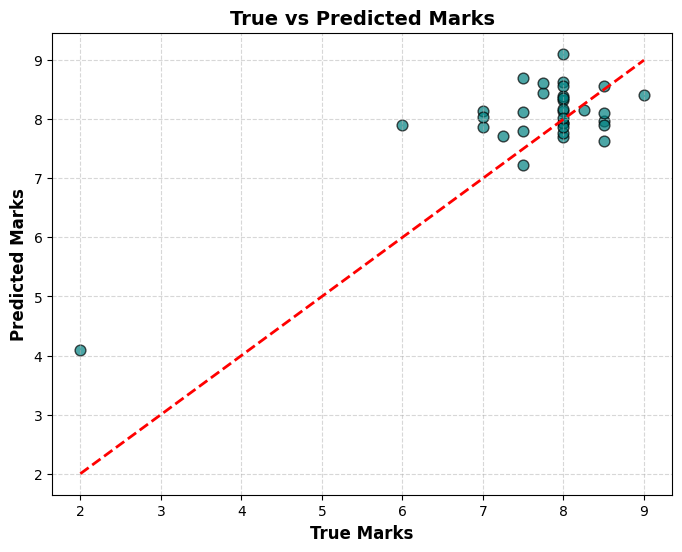

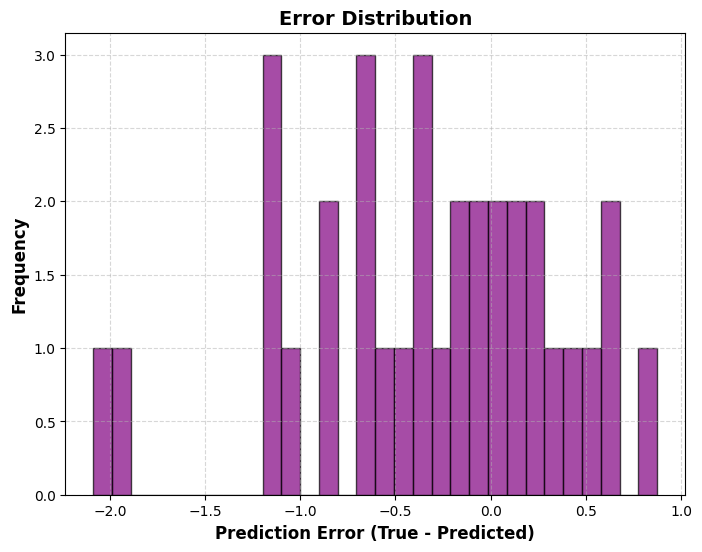

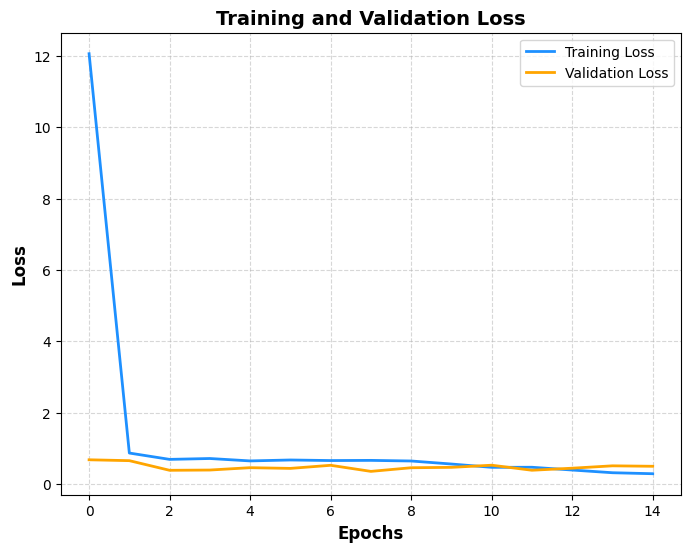

In [6]:
# Scatter plot of true vs predicted marks for the test set
plt.figure(figsize=(8, 6))
plt.scatter(test_actuals, test_predictions, alpha=0.7, c='teal', edgecolors='black', s=60)
plt.plot([min(test_actuals), max(test_actuals)], [min(test_actuals), max(test_actuals)], color='red', linestyle='--', linewidth=2)
plt.xlabel('True Marks', fontsize=12, weight='bold')
plt.ylabel('Predicted Marks', fontsize=12, weight='bold')
plt.title('True vs Predicted Marks', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Calculate errors
errors = np.array(test_actuals) - np.array(test_predictions)

# Histogram of errors
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Prediction Error (True - Predicted)', fontsize=12, weight='bold')
plt.ylabel('Frequency', fontsize=12, weight='bold')
plt.title('Error Distribution', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Training Loss", color='dodgerblue', linewidth=2)
plt.plot(val_losses, label="Validation Loss", color='orange', linewidth=2)
plt.xlabel("Epochs", fontsize=12, weight='bold')
plt.ylabel("Loss", fontsize=12, weight='bold')
plt.title("Training and Validation Loss", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
